In [ ]:
%pip install -q pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# imports and data loading
import re
import os
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

SAVE_DIR = r"C:\Users\hivan\Downloads\eda_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(r"C:\Users\hivan\Downloads\train.csv", escapechar="\\", on_bad_lines="skip", engine="python")
test_df = pd.read_csv(r"C:\Users\hivan\Downloads\test.csv")

print(df.shape)
df.head(3)

(50000, 3)


,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,999b3d4d5a860725bf9528910b5612f3,A simple smiley face with a wide open mouth an...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,1aaa84517819c25f783ae1c0cb337fc5,The image features a black-outlined icon of a ...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


In [ ]:
# nulls, dupes, basic validity
print(df.isnull().sum())
print(f"duplicate svgs: {df['svg'].duplicated().sum()}")
print(f"starts with <svg: {df['svg'].str.startswith('<svg', na=False).sum()}")

id        0
prompt    0
svg       0
dtype: int64
duplicate svgs: 7
starts with <svg: 50000


train:
count    50000.0
mean        19.7
std         10.3
min          1.0
25%         12.0
50%         17.0
75%         24.0
max        127.0
Name: prompt_words, dtype: float64

test:
count    1000.0
mean       20.1
std        10.8
min         2.0
25%        13.0
50%        17.0
75%        24.2
max        85.0
Name: prompt_words, dtype: float64


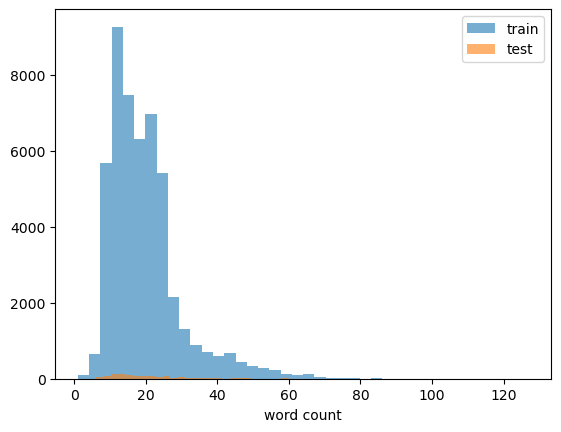

In [ ]:
# prompt word length distribution — train vs test
df["prompt_words"] = df["prompt"].str.split().str.len()
test_df["prompt_words"] = test_df["prompt"].str.split().str.len()

print("train:")
print(df["prompt_words"].describe().round(1))
print("\ntest:")
print(test_df["prompt_words"].describe().round(1))

plt.hist(df["prompt_words"], bins=40, alpha=0.6, label="train")
plt.hist(test_df["prompt_words"], bins=40, alpha=0.6, label="test")
plt.xlabel("word count")
plt.legend()
plt.savefig(os.path.join(SAVE_DIR, "prompt_length.png"))
plt.show()

count    50000.0
mean      2524.0
std       1774.0
min         91.0
50%       2110.0
75%       3530.0
90%       5100.0
95%       6078.0
99%       7514.0
max      15937.0
Name: svg_len, dtype: float64
over 16000 chars: 0


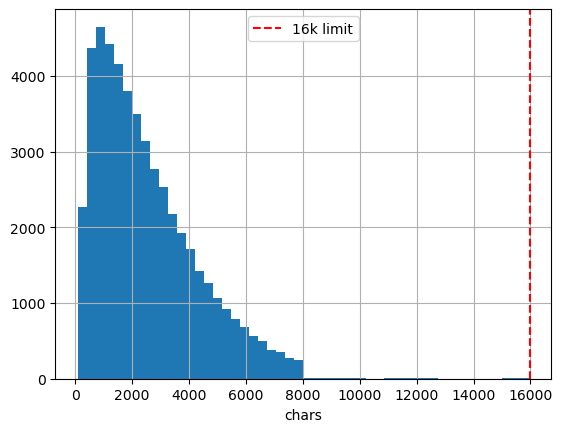

In [ ]:
# svg character length and competition limit check
df["svg_len"] = df["svg"].str.len()
print(df["svg_len"].describe(percentiles=[.75,.90,.95,.99]).round(0))
print(f"over 16000 chars: {(df['svg_len'] > 16000).sum()}")

df["svg_len"].clip(upper=16000).hist(bins=50)
plt.axvline(16000, color="red", linestyle="--", label="16k limit")
plt.xlabel("chars")
plt.legend()
plt.savefig(os.path.join(SAVE_DIR, "svg_char_length.png"))
plt.show()

In [ ]:
# viewbox distribution
df["viewbox"] = df["svg"].str.extract(r'viewBox="([^"]+)"')
print(df["viewbox"].value_counts().head(10))

viewbox
0.0 0.0 200.0 200.0    40892
0 0 24 24               2104
0 0 128 128              902
0 0 400 400              734
0 0 32 32                655
0 0 512 512              494
0 0 200 200              491
0 0 100 100              469
0 0 48 48                373
0 0 64 64                304
Name: count, dtype: int64


In [ ]:

FLOAT_PATTERN = re.compile(r'\d+\.\d{3,}')

df["has_long_floats"] = df["svg"].str.contains(FLOAT_PATTERN, na=False)
print(f"svgs with 3+ decimal floats: {df['has_long_floats'].sum()} ({100*df['has_long_floats'].mean():.1f}%)")

ex = df[df["has_long_floats"]]["svg"].iloc[0]
print(f"example floats found: {FLOAT_PATTERN.findall(ex)[:10]}")

svgs with 3+ decimal floats: 40999 (82.0%)
example floats found: ['93.30000305175781', '21.20000457763672', '93.30000305175781', '80.4000015258789', '21.20000457763672', '80.4000015258789', '21.20000457763672', '179.60000610351562', '120.4000015258789', '179.60000610351562']


In [ ]:
# effect of rounding floats on character length
ROUND_PATTERN = re.compile(r'\d+\.\d+')

def reduce_decimals(svg):
    if not isinstance(svg, str):
        return svg
    return ROUND_PATTERN.sub(lambda m: f"{float(m.group()):.1f}".rstrip('0').rstrip('.'), svg)

sample = df.sample(n=5000, random_state=42).copy()
sample["svg_cleaned"] = sample["svg"].apply(reduce_decimals)
sample["len_after"] = sample["svg_cleaned"].str.len()

print(f"mean chars before: {sample['svg_len'].mean():.0f}")
print(f"mean chars after:  {sample['len_after'].mean():.0f}")
print(f"avg reduction:     {(1 - sample['len_after']/sample['svg_len']).mean()*100:.1f}%")

mean chars before: 2504
mean chars after:  1115
avg reduction:     46.5%


In [ ]:
# disallowed tag check using regex
DISALLOWED = re.compile(r'<(script|animate|animateTransform|animateMotion|set|foreignObject)[\s/>]', re.IGNORECASE)

df["has_disallowed"] = df["svg"].str.contains(DISALLOWED, na=False)
print(f"svgs with disallowed tags: {df['has_disallowed'].sum()} ({100*df['has_disallowed'].mean():.2f}%)")

svgs with disallowed tags: 0 (0.00%)


C:\Users\hivan\AppData\Local\Temp\ipykernel_3188\1308795063.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_disallowed"] = df["svg"].str.contains(DISALLOWED, na=False)


In [ ]:
# approximate token length — 4 chars per token is standard estimate for SVG/code
CHARS_PER_TOKEN = 4
MAX_SEQ_LEN = 2048
PROMPT_OVERHEAD = 100

sample["approx_svg_tokens"] = (sample["len_after"] / CHARS_PER_TOKEN).astype(int)
sample["fits_in_window"] = (sample["approx_svg_tokens"] + PROMPT_OVERHEAD) <= MAX_SEQ_LEN

fits = sample["fits_in_window"].sum()
print(f"svgs that fit fully: {fits} / {len(sample)} ({100*fits/len(sample):.1f}%)")
print(f"svgs that get truncated: {len(sample)-fits} ({100*(len(sample)-fits)/len(sample):.1f}%)")
print(sample["approx_svg_tokens"].describe(percentiles=[.75,.90,.95,.99,.999]).round(0))

svgs that fit fully: 4997 / 5000 (99.9%)
svgs that get truncated: 3 (0.1%)
count    5000.0
mean      278.0
std       179.0
min        34.0
50%       236.0
75%       364.0
90%       500.0
95%       588.0
99%       764.0
99.9%    1680.0
max      3058.0
Name: approx_svg_tokens, dtype: float64


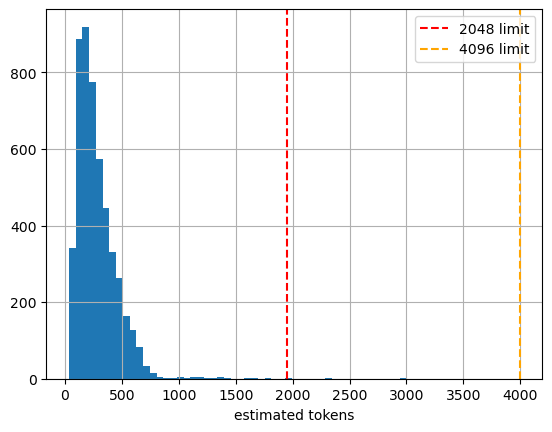

In [ ]:
# token length histogram
sample["approx_svg_tokens"].clip(upper=3000).hist(bins=50)
plt.axvline(MAX_SEQ_LEN - PROMPT_OVERHEAD, color="red", linestyle="--", label="2048 limit")
plt.axvline(4096 - PROMPT_OVERHEAD, color="orange", linestyle="--", label="4096 limit")
plt.xlabel("estimated tokens")
plt.legend()
plt.savefig(os.path.join(SAVE_DIR, "svg_token_length.png"))
plt.show()

In [ ]:
# rows kept at different cutoffs — use this to decide max_seq_length
for pct in [0.90, 0.95, 0.98, 0.99, 0.999]:
    cutoff = int(sample["approx_svg_tokens"].quantile(pct))
    rows_dropped = int((1 - pct) * 50000)
    print(f"keep {pct*100:.1f}% → cutoff={cutoff} tokens → ~{rows_dropped} rows dropped from 50k")

p99 = sample["approx_svg_tokens"].quantile(0.99)
print(f"\nif max_seq_length=2048 → drop ~{(sample['approx_svg_tokens'] + PROMPT_OVERHEAD > 2048).mean()*50000:.0f} rows from 50k")
print(f"if max_seq_length=4096 → drop ~{(sample['approx_svg_tokens'] + PROMPT_OVERHEAD > 4096).mean()*50000:.0f} rows from 50k")


keep 90.0% → cutoff=500 tokens → ~4999 rows dropped from 50k
keep 95.0% → cutoff=588 tokens → ~2500 rows dropped from 50k
keep 98.0% → cutoff=673 tokens → ~1000 rows dropped from 50k
keep 99.0% → cutoff=764 tokens → ~500 rows dropped from 50k
keep 99.9% → cutoff=1680 tokens → ~50 rows dropped from 50k

if max_seq_length=2048 → drop ~30 rows from 50k
if max_seq_length=4096 → drop ~0 rows from 50k
